In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme()

In [7]:
data_single_writer = [
# protocol, gc, topo, converge_round, converge_time, traffic, data_transfer

("push","no_gc","k1",92,460,10.818,10921029,61639,47955),
("push","no_gc","k2",91,455,18.678,13630360,75592,54660),
("push","no_gc","k3",89,445,24.645,15789689,88755,63577),
("push","no_gc","k4",88,440,28.901,17059406,94960,66532),
("push","no_gc","tree",80,400,17.273,9027180,52321,33114),

("push","gc","k1",85,425,10.818,9769665,54663,42453),
("push","gc","k2",84,420,18.678,11931795,66754, 47425),
("push","gc","k3",79,395,24.645,14200935,78336,56242),
("push","gc","k4",81,405,28.901,15107815,84251,58373),
("push","gc","tree",82,410,17.273,7894120,46297,29124),

("pull","no_gc","k1",92,460,40.017,5866252,41870,9003),
("pull","no_gc","k2",94,470,60.273,8294123,64079,12638),
("pull","no_gc","k3",93,465,70.372,11401496,71370,11027),
("pull","no_gc","k4",54,270,29.893,13806376,51272,14370),
("pull","no_gc","tree",83,415,46.645,714151,51644,15161),

("pull","gc","k1",107,535,40.380,5187885,36415,7795),
("pull","gc","k2",107,535,64.579,7243917,56355,10948),
("pull","gc","k3",106,530,76.256,6921462,62314,9683),
("pull","gc","k4",28,140,60.959,6248328,22200,6450),
("pull","gc","tree",101,505,48.678,578069,45797,13299),
]



In [8]:
data_three_writer = [

("push","no_gc","k1",92,460,10.818,20167846,116837,100535),
("push","no_gc","k2",91,455,18.463,22946793,133277,108898),
("push","no_gc","k3",89,445,23.884,26085521,149363,118814),
("push","no_gc","k4",88,440,27.554,26897722,155289,122062),
("pull","no_gc","k1",92,460,34.529,9571615,67213,37050),
("pull","no_gc","k2",94,470,55.438,14603849,107585,53288),
("pull","no_gc","k3",93,465,58.661,15033745,109060,53412),
("pull","no_gc","k4",54,270,66.620,14540867,121061,56239),
]


In [9]:

cols = [
    "protocol","gc","topology",
    "converge_round","converge_time",
    "traffic","total_data_transfer",
    "total_objects","total_delta_objects"
]

df_single = pd.DataFrame(data_single_writer, columns=cols)
df_single["writers"] = "single"

df_single["config"] = "single_" + df_single["protocol"] + "_" + df_single["gc"]

df_single["delta_ratio"] = (
    df_single["total_delta_objects"] /
    df_single["total_objects"]
)

df_three = pd.DataFrame(data_three_writer, columns=cols)
df_three["writers"] = "three"

df_three["config"] = "three_" + df_three["protocol"] + "_" + df_three["gc"]

df_three["delta_ratio"] = (
    df_three["total_delta_objects"] /
    df_three["total_objects"]
)
df_combined = pd.concat([df_single, df_three], ignore_index=True)

topo_order = ["k1","k2","k3","k4","tree"]

In [5]:
# df_single
# df_three

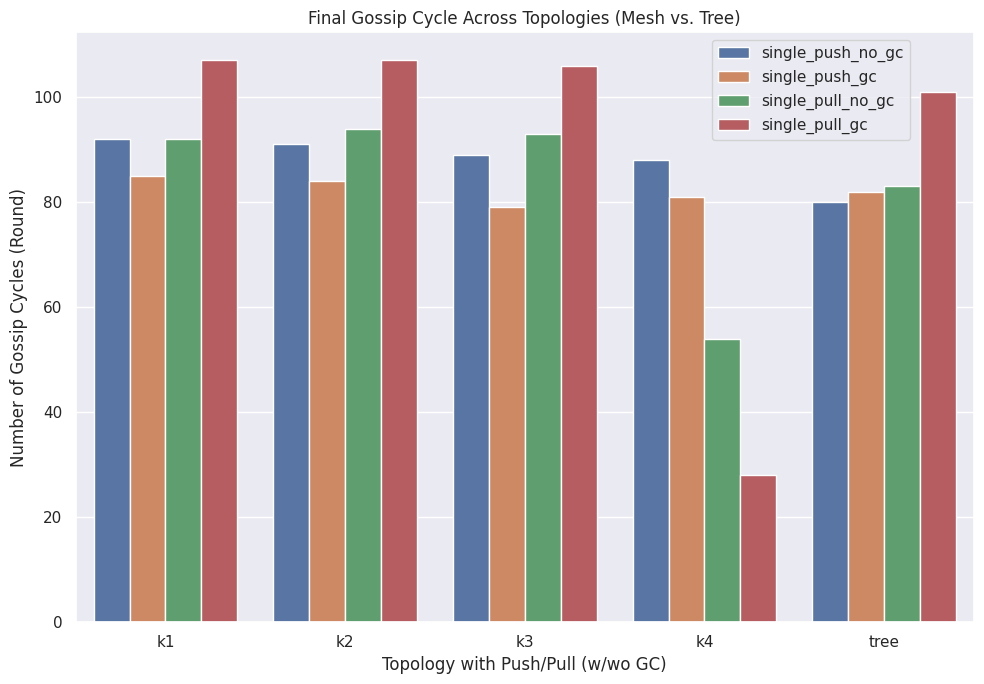

In [6]:
plt.figure(figsize=(10,7))
sns.barplot(
    data=df_single[df_single["writers"]=="single"],
    x="topology",
    y="converge_round",
    hue="config",
    order=topo_order,
    errorbar=None
)
plt.ylabel("Number of Gossip Cycles (Round)")
plt.xlabel("Topology with Push/Pull (w/wo GC)")
plt.title("Final Gossip Cycle Across Topologies (Mesh vs. Tree)")
plt.legend(loc='upper left', bbox_to_anchor=(.7, 1))
plt.tight_layout()
# plt.tight_layout()
plt.savefig("plot1_convergence_time_single.jpeg", bbox_inches="tight")
plt.show()


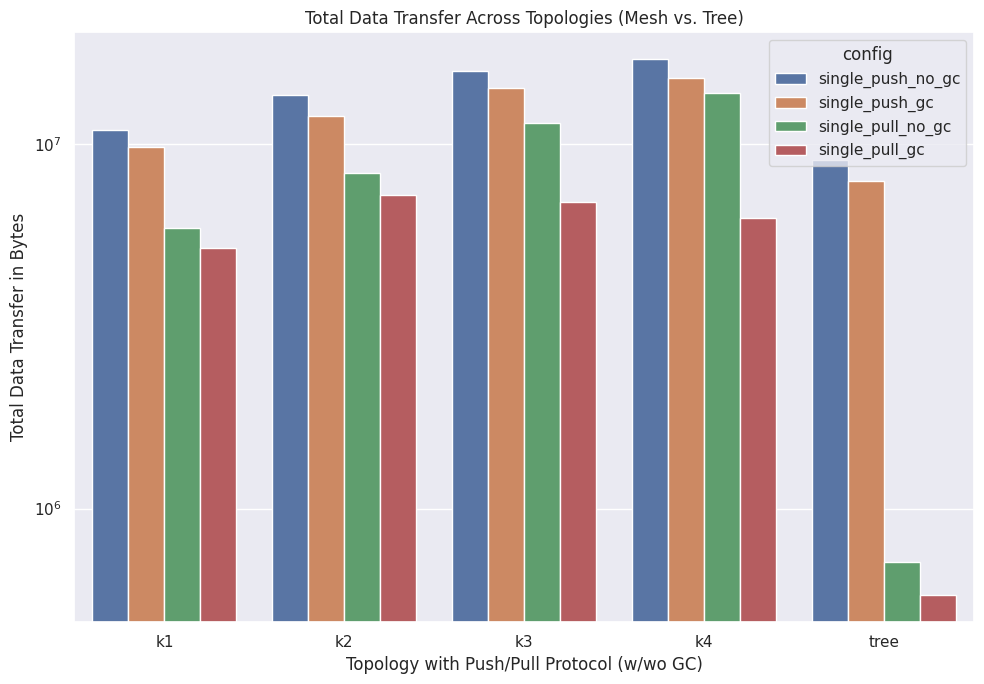

In [10]:
plt.figure(figsize=(10,7))
sns.barplot(
    data=df_single[df_single["writers"]=="single"],
    x="topology",
    y="total_data_transfer",
    # hue="protocol",
    hue="config",
    order=topo_order,
    errorbar=None
)

plt.ylabel("Total Data Transfer in Bytes")
plt.xlabel("Topology with Push/Pull Protocol (w/wo GC)")
plt.yscale("log")
plt.title("Total Data Transfer Across Topologies (Mesh vs. Tree)")
plt.tight_layout()
plt.savefig("plot2_data_transfer_single.jpeg", bbox_inches="tight")
plt.show()


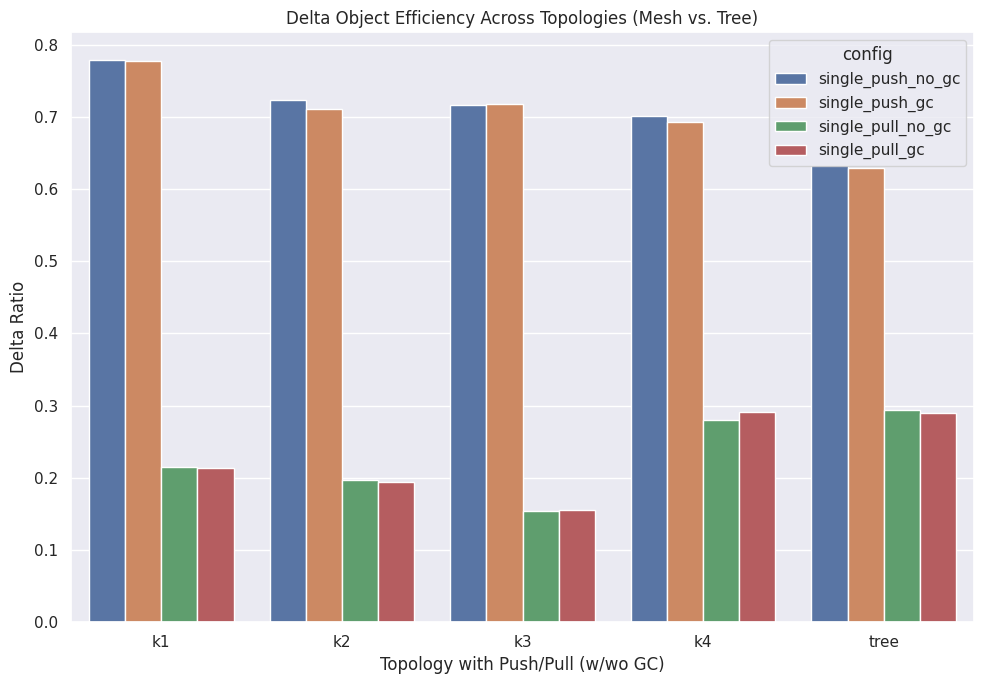

In [8]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=df_single[df_single["writers"]=="single"],
    x="topology",
    y="delta_ratio",
    hue="config",
    order=topo_order,
    errorbar=None
)

plt.ylabel("Delta Ratio")
plt.xlabel("Topology with Push/Pull (w/wo GC)")
plt.title("Delta Object Efficiency Across Topologies (Mesh vs. Tree)")
plt.tight_layout()
plt.savefig("plot3_delta_efficiency_single.jpeg", bbox_inches="tight")
plt.show()


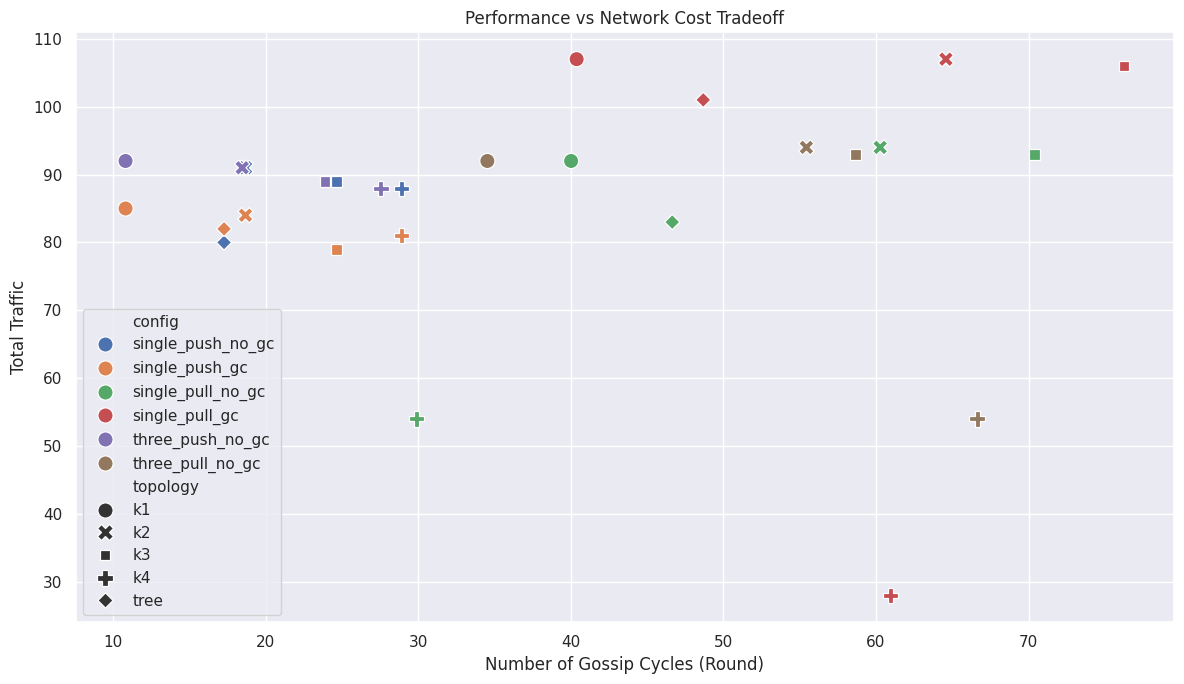

In [6]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_combined,
    y="converge_round",
    x="traffic",
    hue="config",
    style="topology",
    s=120
)

plt.xlabel("Number of Gossip Cycles (Round)")
plt.ylabel("Total Traffic")
plt.title("Performance vs Network Cost Tradeoff")
plt.tight_layout()
# plt.legend(loc='upper left', bbox_to_anchor=(1, 0.55))
# plt.savefig("plot4_tradeoff_scatter.jpeg", bbox_inches="tight")
plt.show()



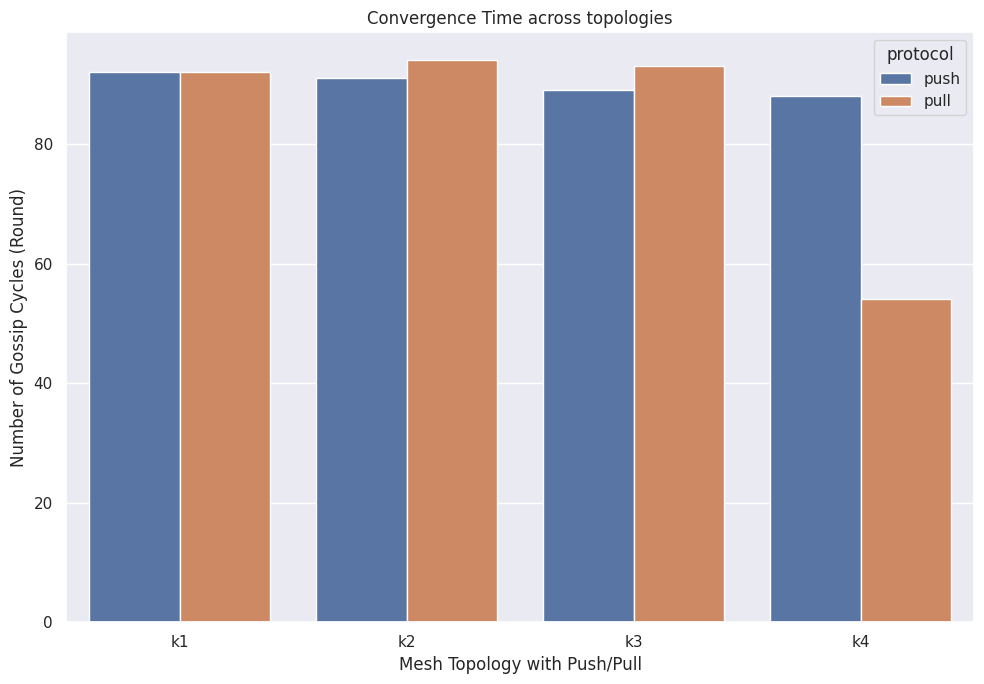

In [13]:
plt.figure(figsize=(10,7))
sns.barplot(
    data=df_three[df_three["writers"]=="three"],
    x="topology",
    y="converge_round",
    hue="protocol",
    order=topo_order[:-1],
    errorbar=None
)
plt.ylabel("Number of Gossip Cycles (Round)")
plt.xlabel("Mesh Topology with Push/Pull")
plt.title("Convergence Time across topologies")
# plt.legend(loc='upper left', bbox_to_anchor=(.7, 1))
plt.tight_layout()
# plt.tight_layout()
plt.savefig("plot6_convergence_time_three.jpeg", bbox_inches="tight")
plt.show()


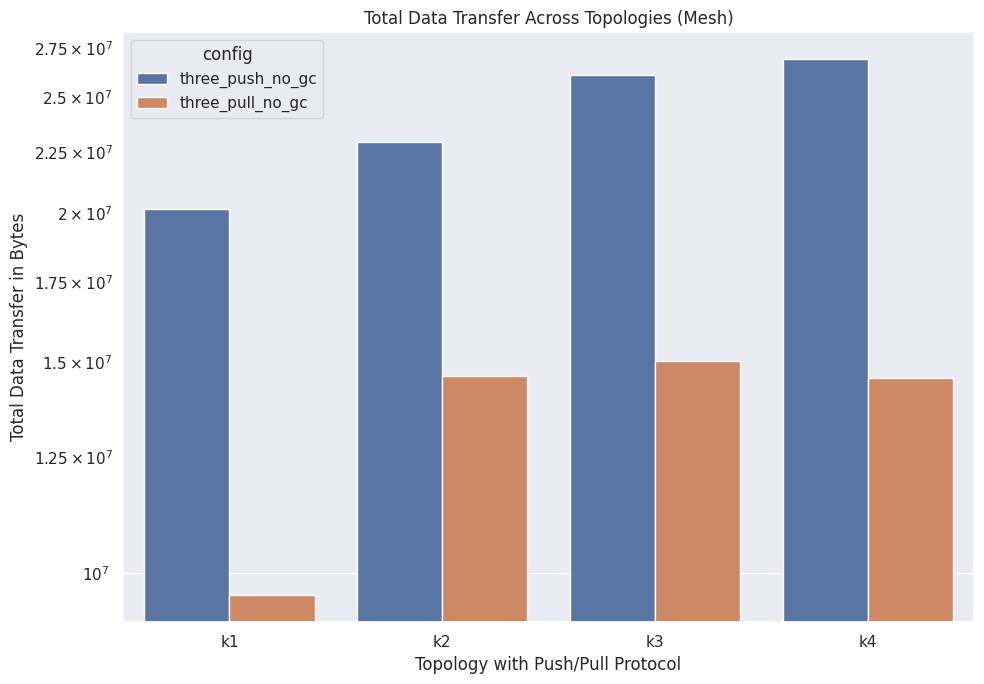

In [11]:
plt.figure(figsize=(10,7))
sns.barplot(
    data=df_three[df_three["writers"]=="three"],
    x="topology",
    y="total_data_transfer",
    # hue="protocol",
    hue="config",
    order=topo_order[:-1],
    errorbar=None
)

plt.ylabel("Total Data Transfer in Bytes")
plt.xlabel("Topology with Push/Pull Protocol")
plt.yscale("log")
plt.title("Total Data Transfer Across Topologies (Mesh)")
plt.tight_layout()
plt.savefig("plot7_data_transfer_three.jpeg", bbox_inches="tight")
plt.show()


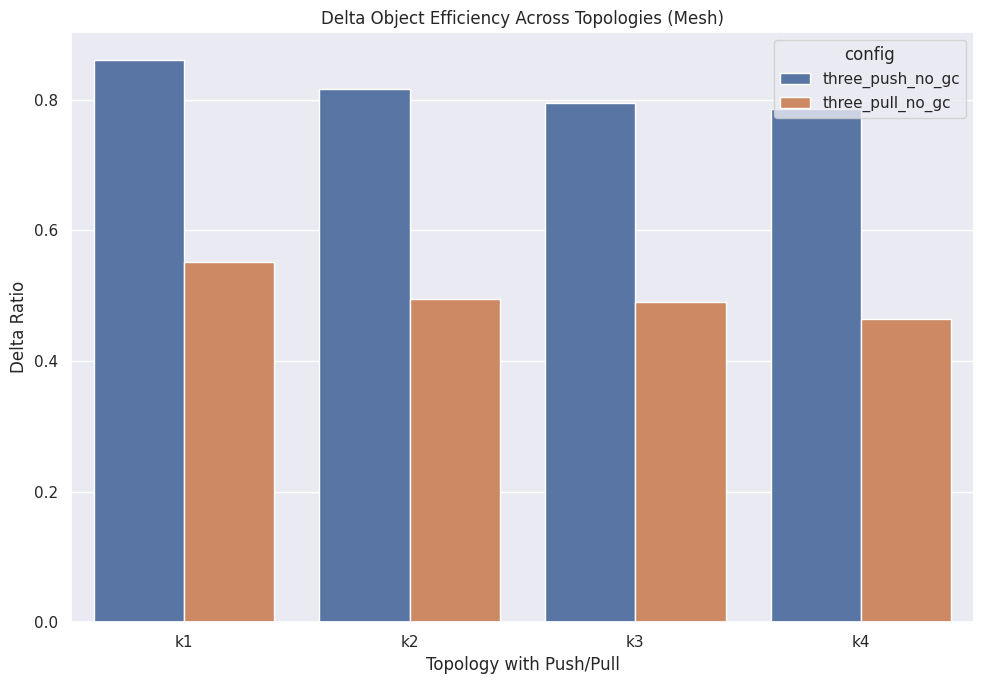

In [12]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=df_three[df_three["writers"]=="three"],
    x="topology",
    y="delta_ratio",
    hue="config",
    order=topo_order[:-1],
    errorbar=None
)

plt.ylabel("Delta Ratio")
plt.xlabel("Topology with Push/Pull")
plt.title("Delta Object Efficiency Across Topologies (Mesh)")
plt.tight_layout()
plt.savefig("plot8_delta_efficiency_three.jpeg", bbox_inches="tight")
plt.show()
